# Rasing the Stakes
**Supplementary material for UMAP 2026 Submission**

Notebook for running Appropriateness of Reliance Analysis 

In [1]:
import sys
sys.path.append('../')

In [2]:
from pathlib import Path
import numpy as np 

import pandas as pd

from scipy.stats import mannwhitneyu, shapiro, bootstrap
import bambi as bmb
import arviz as az

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import metrics
sns.set(style="whitegrid")

# Notebook and File Paths Setup

In [3]:
results_basepath = Path('data') 
df_low = pd.read_csv(results_basepath / 'per_sample_results_low.csv')
df_high = pd.read_csv(results_basepath / 'per_sample_results_high.csv')
df_all = pd.concat([df_low, df_high], axis=0).reset_index(drop=True)

df_all["stakes_level"] = pd.Categorical(
    df_all["stakes_level"],
    categories=["low", "high"],  # first = reference
    ordered=True
)
df_all['time_taken_advised'] = df_all['time_taken_advised'] / 1000  # convert ms to s
df_all['z_time_taken_advised'] = (df_all['time_taken_advised'] - df_all['time_taken_advised'].mean()) / df_all['time_taken_advised'].std()

df_low = df_all[df_all['stakes_level'] == 'low'].copy()
df_high = df_all[df_all['stakes_level'] == 'high'].copy()

# Appropiateness of Reliance Analysis

## Processing of Data

In [4]:
# calculate all metrics for Appropriateness of Reliance (AoR) framework - low stakes
user_AoRs_low = []
user_ids = df_low['part_id'].unique()
for i, uid in enumerate(user_ids):
    df_part = df_low[df_low['part_id'] == uid]
    AoR = metrics.calc_AoR(y_true=df_part['y_true'], 
                           y_model=df_part['y_pred'],
                           y_user_base=df_part['y_user_base'],
                           y_user_advised=df_part['y_user_advised'])
    user_AoRs_low.append(AoR)
user_AoRs_low = np.array(user_AoRs_low)

rair_low = user_AoRs_low[:, 0]
rsr_low = user_AoRs_low[:, 1]

In [5]:
# calculate all metrics for Appropriateness of Reliance (AoR) framework - high stakes
user_AoRs_high = []
user_ids = df_high['part_id'].unique()
for i, uid in enumerate(user_ids):
    df_part = df_high[df_high['part_id'] == uid]
    AoR = metrics.calc_AoR(y_true=df_part['y_true'], 
                           y_model=df_part['y_pred'],
                           y_user_base=df_part['y_user_base'],
                           y_user_advised=df_part['y_user_advised'])
    user_AoRs_high.append(AoR)
user_AoRs_high = np.array(user_AoRs_high)
user_AoRs_high.shape

rair_high = user_AoRs_high[:, 0]
rsr_high = user_AoRs_high[:, 1]

## AoR Stats & Visualization

In [6]:
# Calculate medians and confidence intervals for both conditions since data is not normally distributed

median_low_x = np.median(rair_low)
median_low_y = np.median(rsr_low)
ci_low_x = bootstrap((rair_low,), np.median, confidence_level=0.95, n_resamples=10000, method='percentile').confidence_interval
ci_low_y = bootstrap((rsr_low,), np.median, confidence_level=0.95, n_resamples=10000, method='percentile').confidence_interval

median_high_x = np.median(rair_high)
median_high_y = np.median(rsr_high)
ci_high_x = bootstrap((rair_high,), np.median, confidence_level=0.95, n_resamples=10000, method='percentile').confidence_interval
ci_high_y = bootstrap((rsr_high,), np.median, confidence_level=0.95, n_resamples=10000, method='percentile').confidence_interval

x_low = median_low_x
x_err_low = np.array([[median_low_x - ci_low_x.low], [ci_low_x.high - median_low_x]])
x_high = median_high_x
x_err_high = np.array([[median_high_x - ci_high_x.low], [ci_high_x.high - median_high_x]])

y_low = median_low_y
y_err_low = np.array([[median_low_y - ci_low_y.low], [ci_low_y.high - median_low_y]])
y_high = median_high_y
y_err_high = np.array([[median_high_y - ci_high_y.low], [ci_high_y.high - median_high_y]])

print(f'RAIR Low Stakes: Median={median_low_x:.3f}, 95% CI=({ci_low_x.low:.3f}, {ci_low_x.high:.3f})')
print(f'RAIR High Stakes: Median={median_high_x:.3f}, 95% CI=({ci_high_x.low:.3f}, {ci_high_x.high:.3f})')
print(f'RSR Low Stakes: Median={median_low_y:.3f}, 95% CI=({ci_low_y.low:.3f}, {ci_low_y.high:.3f})')
print(f'RSR High Stakes: Median={median_high_y:.3f}, 95% CI=({ci_high_y.low:.3f}, {ci_high_y.high:.3f})')

RAIR Low Stakes: Median=0.613, 95% CI=(0.462, 0.750)
RAIR High Stakes: Median=0.667, 95% CI=(0.542, 0.707)
RSR Low Stakes: Median=0.667, 95% CI=(0.500, 0.750)
RSR High Stakes: Median=0.444, 95% CI=(0.375, 0.500)


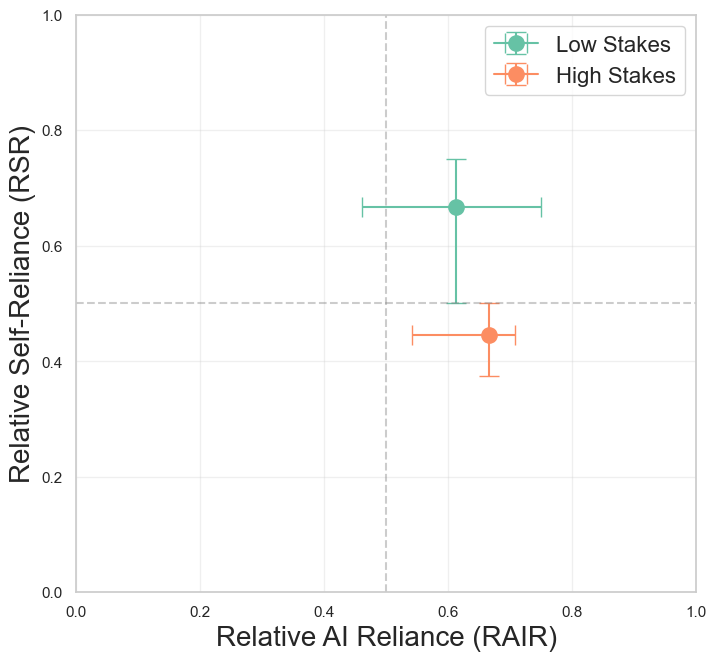

In [7]:
# Create the plot
colors = sns.color_palette("Set2", 2)
plt.figure(figsize=(8, 7.5))
plt.errorbar(x_low, y_low, xerr=x_err_low, yerr=y_err_low, 
  marker='o', markersize=11, label='Low Stakes', capsize=7, color=colors[0])
plt.errorbar(x_high, y_high, xerr=x_err_high, yerr=y_err_high, 
       marker='o', markersize=11, label='High Stakes', capsize=7, color=colors[1])

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.4)

plt.ylim([0, 1])
plt.xlim([0, 1])
plt.xlabel('Relative AI Reliance (RAIR)', fontsize=20)
plt.ylabel('Relative Self-Reliance (RSR)', fontsize=20)

plt.legend(fontsize=16)
plt.grid(True, alpha=0.3)
plt.savefig('output/AoR_plot.png', dpi=300, bbox_inches='tight')
plt.show()

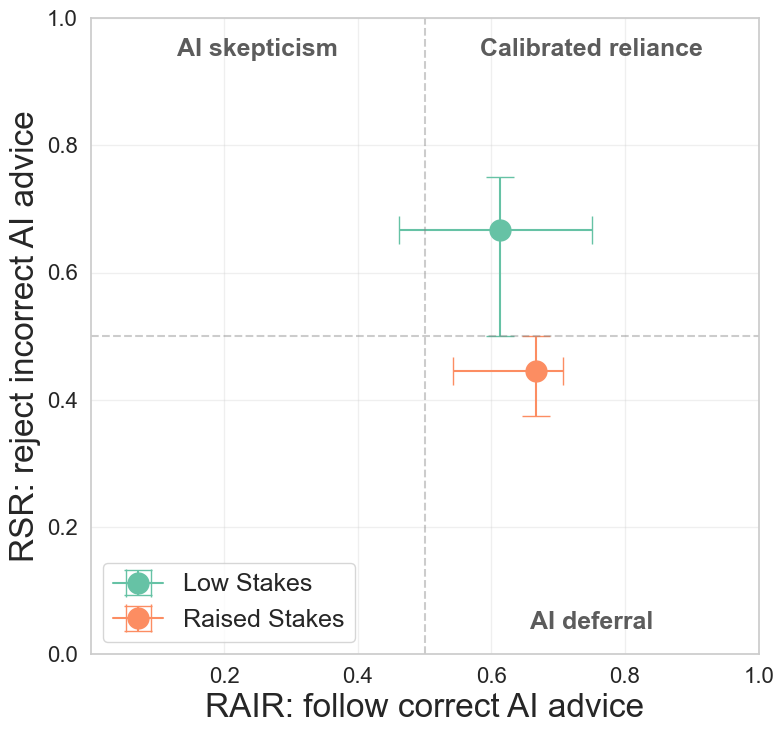

In [8]:
# Create the plot (presentation version)
colors = sns.color_palette("Set2", 2)
plt.figure(figsize=(8, 7.5))
plt.errorbar(x_low, y_low, xerr=x_err_low, yerr=y_err_low, 
  marker='o', markersize=15, label='Low Stakes', capsize=10, color=colors[0])
plt.errorbar(x_high, y_high, xerr=x_err_high, yerr=y_err_high, 
       marker='o', markersize=15, label='Raised Stakes', capsize=10, color=colors[1])

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.4)

plt.text(
    0.25, 0.95,
    "AI skepticism",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold",
    alpha=0.75
)

plt.text(
    0.75, 0.95,
    "Calibrated reliance",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold",
    alpha=0.75
)

plt.text(
    0.75, 0.05,
    "AI deferral",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold",
    alpha=0.75
)

plt.ylim([0, 1])
plt.xlim([0, 1])
plt.xlabel('RAIR: follow correct AI advice', fontsize=24)
plt.ylabel('RSR: reject incorrect AI advice', fontsize=24)
plt.xticks([0.2, 0.4, 0.6, 0.8, 1.0], fontsize=16)
plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=16)
plt.legend(fontsize=18)

plt.grid(True, alpha=0.3)
plt.savefig('output/AoR_plot_pres.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [9]:
# print('---')
# print('For Latex Table:')
print(f'RAIR & {median_low_x:.2f} ({ci_low_x.low:.2f}, {ci_low_x.high:.2f}) & {median_high_x:.2f} ({ci_high_x.low:.2f}, {ci_high_x.high:.2f}) & & \\\\')
print(f'RSR & {median_low_y:.2f} ({ci_low_y.low:.2f}, {ci_low_y.high:.2f}) & {median_high_y:.2f} ({ci_high_y.low:.2f}, {ci_high_y.high:.2f}) & & \\\\')

RAIR & 0.61 (0.46, 0.75) & 0.67 (0.54, 0.71) & & \\
RSR & 0.67 (0.50, 0.75) & 0.44 (0.38, 0.50) & & \\


## AoR Statisical Analysis

In [10]:
## Functions for effect size
def cohen_r_mwu(g1, g2, u):
    n1, n2 = len(g1), len(g2)
    mu_u = n1 * n2 / 2
    sigma_u = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    
    z= (u - mu_u) / sigma_u
    return z / np.sqrt(n1 + n2)

In [11]:
stat, p = shapiro(rair_low)
print(f'Shapiro-Wilk test for RAIR Low Stakes: stat={stat:.4f}, p={p:.4f} - {"Normal" if p < 0.05 else "Not Normal"}')
stat, p = shapiro(rair_high)
print(f'Shapiro-Wilk test for RAIR High Stakes: stat={stat:.4f}, p={p:.4f} - {"Normal" if p < 0.05 else "Not Normal"  }')

Shapiro-Wilk test for RAIR Low Stakes: stat=0.9627, p=0.4952 - Not Normal
Shapiro-Wilk test for RAIR High Stakes: stat=0.9497, p=0.1943 - Not Normal


In [12]:
stat, p = mannwhitneyu(rair_low, rair_high)
effect_size = cohen_r_mwu(rair_low, rair_high, stat)
print(f'Mann-Whitney U test for RAIR Low vs High Stakes: stat={stat}, p={p:.4f}, effect size (r)={effect_size:.4f}')

Mann-Whitney U test for RAIR Low vs High Stakes: stat=299.5, p=0.5076, effect size (r)=-0.0929


In [13]:
stat, p = mannwhitneyu(rsr_low, rsr_high)
effect_size = cohen_r_mwu(rsr_low, rsr_high, stat)
print(f'Mann-Whitney U test for RSR Low vs RSR High Stakes: stat={stat}, p={p:.4f}, effect size (r)={effect_size:.4f}')

Mann-Whitney U test for RSR Low vs RSR High Stakes: stat=433.0, p=0.0758, effect size (r)=0.2469


## Time Effects Analysis

In [14]:
time_col = 'z_time_taken_advised'

In [15]:
def get_CAIR(df):
  cair_cases = (
        (df['y_user_base'] != df['y_true']) & 
        (df['y_pred'] == df['y_true']) & 
        (df['y_user_advised'] == df['y_pred'])
  )
  return cair_cases

def get_IAIR(df):
  iair_cases = (
        (df['y_user_base'] != df['y_true']) & 
        (df['y_pred'] == df['y_true']) & 
        (df['y_user_advised']!= df['y_pred'])
  )
  return iair_cases

def get_CSR(df):
  csr_cases = (
        (df['y_user_base'] == df['y_true']) & 
        (df['y_pred'] != df['y_true']) & 
        (df['y_user_advised'] == df['y_user_base'])
  )
  return csr_cases

def get_ISR(df):
  isr_cases = (
        (df['y_user_base'] == df['y_true']) & 
        (df['y_pred'] != df['y_true']) & 
        (df['y_user_advised'] != df['y_user_base'])
  )
  return isr_cases

In [16]:
cair_high = get_CAIR(df_high)
iair_high = get_IAIR(df_high)
csr_high = get_CSR(df_high)
isr_high = get_ISR(df_high)

cair_low = get_CAIR(df_low)
iair_low = get_IAIR(df_low)
csr_low = get_CSR(df_low)
isr_low = get_ISR(df_low)

### Visualations of Time Effects

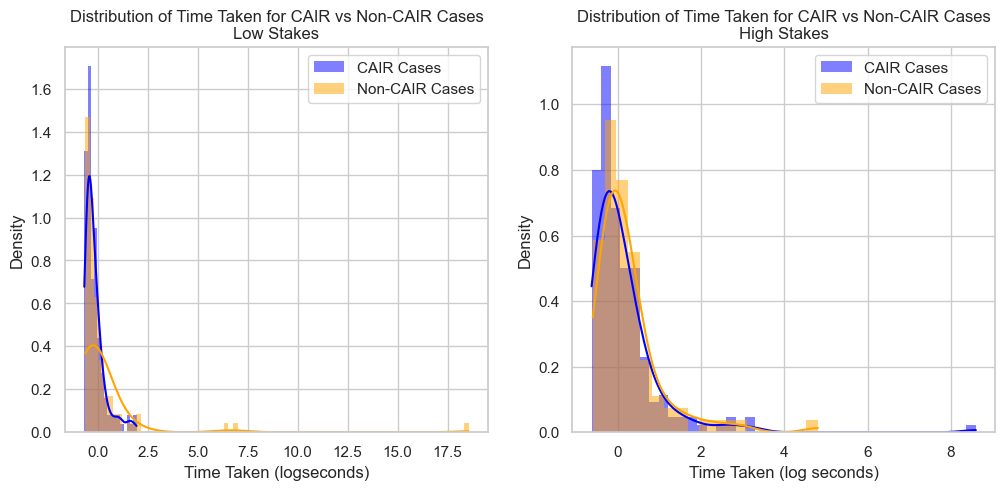

In [17]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_low[cair_low][time_col], color='blue', label='CAIR Cases', kde=True, stat="density", linewidth=0)
sns.histplot(df_low[iair_low][time_col], color='orange', label='Non-CAIR Cases', kde=True, stat="density", linewidth=0)
plt.xlabel('Time Taken (logseconds)')
plt.ylabel('Density')
plt.title('Distribution of Time Taken for CAIR vs Non-CAIR Cases\nLow Stakes')
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(df_high[cair_high][time_col], color='blue', label='CAIR Cases', kde=True, stat="density", linewidth=0)
sns.histplot(df_high[iair_high][time_col], color='orange', label='Non-CAIR Cases', kde=True, stat="density", linewidth=0)
plt.xlabel('Time Taken (log seconds)')
plt.ylabel('Density')
plt.title('Distribution of Time Taken for CAIR vs Non-CAIR Cases\nHigh Stakes')
plt.legend()

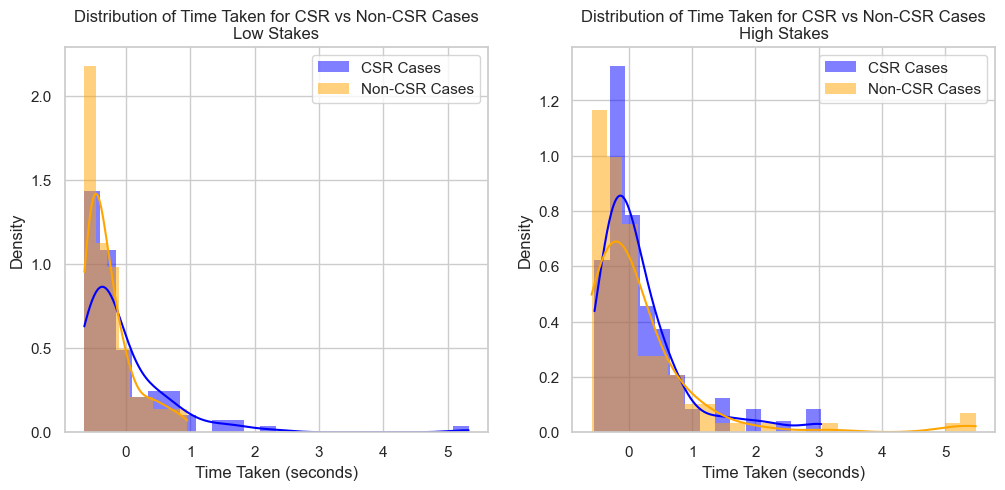

In [18]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_low[csr_low][time_col], color='blue', label='CSR Cases', kde=True, stat="density", linewidth=0)
sns.histplot(df_low[isr_low][time_col], color='orange', label='Non-CSR Cases', kde=True, stat="density", linewidth=0)
plt.xlabel('Time Taken (seconds)')
plt.ylabel('Density')
plt.title('Distribution of Time Taken for CSR vs Non-CSR Cases\nLow Stakes')
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(df_high[csr_high][time_col], color='blue', label='CSR Cases', kde=True, stat="density", linewidth=0)
sns.histplot(df_high[isr_high][time_col], color='orange', label='Non-CSR Cases', kde=True, stat="density", linewidth=0)
plt.xlabel('Time Taken (seconds)')
plt.ylabel('Density')
plt.title('Distribution of Time Taken for CSR vs Non-CSR Cases\nHigh Stakes')
plt.legend()

### Bayesian Mixed-Effects Model of Decision Time on CAIR

In [19]:
def calculate_p_direction(idata, var_name):
    posterior = idata.posterior[var_name].values.flatten()
    p_neg = (posterior < 0).mean()
    p_pos = (posterior > 0).mean()
    p_direction = max(p_neg, p_pos)
    direction = "negative" if p_neg > p_pos else "positive"
    return p_direction, direction

In [20]:
df_all_cair = df_all[get_CAIR(df_all)].copy()
df_all_cair['CAIR'] = 1
df_all_iair = df_all[get_IAIR(df_all)].copy()
df_all_iair['CAIR'] = 0

df_all_comb_cair = pd.concat([df_all_cair, df_all_iair], axis=0, ignore_index=True)
df_all_comb_cair.head()

,part_id,blocky_id,stakes_level,y_true,y_pred,y_user_base,y_user_advised,time_taken_base,time_taken_advised,z_time_taken_advised,CAIR
0,study1-05,0575626d-1155-4f79-a8ed-151c82499cee,low,0,0,1,0,2596.0,3.797,-0.364812,1
1,study1-05,0a43a265-1afa-47a5-807e-402622e5b3c8,low,0,0,1,0,2010.0,4.397,-0.286653,1
2,study1-05,2fdd906b-a9b2-4c4b-b66b-94ab1efb1f97,low,1,1,0,1,3791.0,2.567,-0.525038,1
3,study1-05,6ee36074-0245-4135-b404-3158ecbfe6f5,low,1,1,0,1,4240.0,5.688,-0.118480,1
4,study1-05,a9560d62-361e-4028-b078-95afbe555b02,low,1,1,0,1,2483.0,3.702,-0.377187,1


In [21]:
model_cair = bmb.Model(
    f"CAIR ~ {time_col} * stakes_level + (1|part_id) + (1|blocky_id)",
    df_all_comb_cair,
    family="bernoulli"
)

idata_cair = model_cair.fit(draws=2000, chains=4, target_accept=0.9)
az.summary(idata_cair, var_names=[time_col, "stakes_level", f"{time_col}:stakes_level"], hdi_prob=0.95)

Modeling the probability that CAIR==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, z_time_taken_advised, stakes_level, z_time_taken_advised:stakes_level, 1|part_id_sigma, 1|part_id_offset, 1|blocky_id_sigma, 1|blocky_id_offset]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 38 seconds.


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
z_time_taken_advised,-0.547,0.238,-1.025,-0.118,0.003,0.002,6384.0,5906.0,1.0
stakes_level[high],0.324,0.333,-0.317,0.981,0.005,0.003,4585.0,5100.0,1.0
z_time_taken_advised:stakes_level[high],0.355,0.285,-0.187,0.950,0.003,0.003,6926.0,5671.0,1.0


In [22]:
post = idata_cair.posterior

p_direction_time, direction_time = calculate_p_direction(idata_cair, time_col)
p_direction_stakes, direction_stakes = calculate_p_direction(idata_cair, "stakes_level")
p_direction_time_stakes, direction_time_stakes = calculate_p_direction(idata_cair, f"{time_col}:stakes_level")

print(f'Posterior probability that {time_col} has a {direction_time} effect on CAIR: {p_direction_time:.4f}')
print(f'Posterior probability that stakes_level[high] has a {direction_stakes} effect on CAIR: {p_direction_stakes:.4f}')
print(f'Posterior probability that interaction {time_col}:stakes_level[high] has a {direction_time_stakes} effect on CAIR: {p_direction_time_stakes:.4f}')

Posterior probability that z_time_taken_advised has a negative effect on CAIR: 0.9981
Posterior probability that stakes_level[high] has a positive effect on CAIR: 0.8361
Posterior probability that interaction z_time_taken_advised:stakes_level[high] has a positive effect on CAIR: 0.8986


In [23]:
az.summary(
    idata_cair,
    var_names=["1|part_id_sigma", "1|blocky_id_sigma"],
    hdi_prob=0.95
)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
1|part_id_sigma,0.955,0.182,0.595,1.307,0.003,0.002,3272.0,4527.0,1.0
1|blocky_id_sigma,0.445,0.177,0.082,0.779,0.004,0.002,1777.0,1249.0,1.0


In [24]:
# calc odds ratios for for estimates
cair_time_est = -0.55
cair_stakes_est = 0.32
cair_interaction_est = 0.37

print('CAIR Odds Ratios:')
print('Time:', np.exp(cair_time_est))
print('Stakes:', np.exp(cair_stakes_est))
print('Interaction:', np.exp(cair_interaction_est))

CAIR Odds Ratios:
Time: 0.5769498103804866
Stakes: 1.3771277643359572
Interaction: 1.4477346146633245


### Bayesian Mixed-Effects Model of Decision Time on CSR

In [25]:
df_all_csr = df_all[get_CSR(df_all)].copy()
df_all_csr['CSR'] = 1
df_all_isr = df_all[get_ISR(df_all)].copy()
df_all_isr['CSR'] = 0

df_all_comb_csr = pd.concat([df_all_csr, df_all_isr], axis=0, ignore_index=True)
df_all_comb_csr.head()

,part_id,blocky_id,stakes_level,y_true,y_pred,y_user_base,y_user_advised,time_taken_base,time_taken_advised,z_time_taken_advised,CSR
0,study1-05,0ec401e3-48a9-44e3-807c-e950d9f84760,low,0,1,0,0,2670.0,4.608,-0.259167,1
1,study1-05,1d690c7b-c566-482d-8940-2386ee5d5364,low,1,0,1,1,2128.0,2.800,-0.494686,1
2,study1-05,1fb1acfc-03c9-4a6e-b57a-e930051d04ca,low,1,0,1,1,2249.0,2.930,-0.477752,1
3,study1-05,22a11fec-8675-45c9-a24b-9a909bf9ea1d,low,1,0,1,1,2382.0,2.470,-0.537674,1
4,study1-05,66651fd4-ef75-4ce3-a1d2-255281116423,low,1,0,1,1,2400.0,2.812,-0.493123,1


In [26]:
model_csr = bmb.Model(
    f"CSR ~ {time_col} * stakes_level + (1|part_id) + (1|blocky_id)",
    df_all_comb_csr,
    family="bernoulli"
)

idata_csr = model_csr.fit(draws=2000, chains=4, target_accept=0.9)
az.summary(idata_csr, var_names=[time_col, "stakes_level", f"{time_col}:stakes_level"], hdi_prob=0.95)

Modeling the probability that CSR==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, z_time_taken_advised, stakes_level, z_time_taken_advised:stakes_level, 1|part_id_sigma, 1|part_id_offset, 1|blocky_id_sigma, 1|blocky_id_offset]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 38 seconds.


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
z_time_taken_advised,1.128,0.456,0.220,1.987,0.008,0.005,3547.0,4387.0,1.0
stakes_level[high],-0.747,0.438,-1.581,0.121,0.008,0.005,3004.0,4296.0,1.0
z_time_taken_advised:stakes_level[high],-1.129,0.493,-2.083,-0.169,0.008,0.005,3674.0,4357.0,1.0


In [27]:
post = idata_csr.posterior

p_direction_time, direction_time = calculate_p_direction(idata_csr, time_col)
p_direction_stakes, direction_stakes = calculate_p_direction(idata_csr, "stakes_level")
p_direction_time_stakes, direction_time_stakes = calculate_p_direction(idata_csr, f"{time_col}:stakes_level")

print(f'Posterior probability that {time_col} has a {direction_time} effect on CSR: {p_direction_time:.4f}')
print(f'Posterior probability that stakes_level[high] has a {direction_stakes} effect on CSR: {p_direction_stakes:.4f}')
print(f'Posterior probability that interaction {time_col}:stakes_level[high] has a {direction_time_stakes} effect on CSR: {p_direction_time_stakes:.4f}')

Posterior probability that z_time_taken_advised has a positive effect on CSR: 0.9968
Posterior probability that stakes_level[high] has a negative effect on CSR: 0.9546
Posterior probability that interaction z_time_taken_advised:stakes_level[high] has a negative effect on CSR: 0.9929


In [28]:
az.summary(
    idata_csr,
    var_names=["1|part_id_sigma", "1|blocky_id_sigma"],
    hdi_prob=0.95
)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
1|part_id_sigma,1.423,0.254,0.976,1.962,0.005,0.003,3040.0,5198.0,1.0
1|blocky_id_sigma,0.941,0.283,0.449,1.481,0.006,0.005,2537.0,4290.0,1.0


In [29]:
# calc odds ratios for for estimates
csr_time_est = 1.13
csr_stakes_est = -0.74
csr_interaction_est = -1.13

print('CSR Odds Ratios:')
print('Time:', np.exp(csr_time_est))
print('Stakes:', np.exp(csr_stakes_est))
print('Interaction:', np.exp(csr_interaction_est))

CSR Odds Ratios:
Time: 3.095656500124711
Stakes: 0.4771139155210344
Interaction: 0.32303325642225295
